# Gamma Distribution

The **Gamma distribution** is a flexible two-parameter family for positive, right-skewed data. It generalises the Exponential (shape=1) and Chi-square (shape=ν/2, scale=2), and models waiting times for multiple events, insurance claims, and rainfall amounts.

| Property | Value |
|---|---|
| **Parameters** | $\gamma$ (shape, $\gamma > 0$), $\beta$ (scale, $\beta > 0$), $\mu$ (location) |
| **Support** | $(\mu, +\infty)$ |
| **PDF** | $\displaystyle f(x) = \frac{\left(\frac{x-\mu}{\beta}\right)^{\gamma-1} e^{-(x-\mu)/\beta}}{\beta\,\Gamma(\gamma)}$ |
| **Mean** | $\mu + \gamma\beta$ |
| **Variance** | $\gamma\beta^2$ |
| **Mode** | $\mu + (\gamma-1)\beta$ for $\gamma \geq 1$ |
| **Skewness** | $2/\sqrt{\gamma}$ (decreases as $\gamma \uparrow$) |
| **Special cases** | $\gamma=1 \to \text{Exponential}(\beta)$;  $\gamma=\nu/2, \beta=2 \to \chi^2(\nu)$ |
| **Estimation** | MOM: $\hat{\gamma}=\bar{x}^2/s^2$, $\hat{\beta}=s^2/\bar{x}$; MLE: numerical |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Visualising the Gamma Distribution

### Panel 1 — PDF: From Exponential to Near-Symmetric
Each curve shows the **PDF** of $\text{Gamma}(\gamma, \beta)$ for different shape-scale combinations. Shape $\gamma=1$ gives the Exponential; increasing $\gamma$ shifts the mode right and reduces right-skew, approaching a symmetric bell shape.

### Panel 2 — Gamma as Sum of $k$ Exponentials
Histograms of simulated sums of $k$ independent $\text{Exp}(\beta)$ variables are overlaid with the theoretical $\text{Gamma}(k, \beta)$ PDF, confirming the additive property: sum of $k$ Exponentials is $\text{Gamma}(k, \beta)$.

### Panel 3 — MLE vs Method-of-Moments Estimation
A sample of 300 Gamma observations is fitted using both **MLE** (blue) and **Method of Moments** (red dotted), overlaid with the true PDF (grey dashed). Both methods are close to the true parameters, but MLE is slightly more accurate.


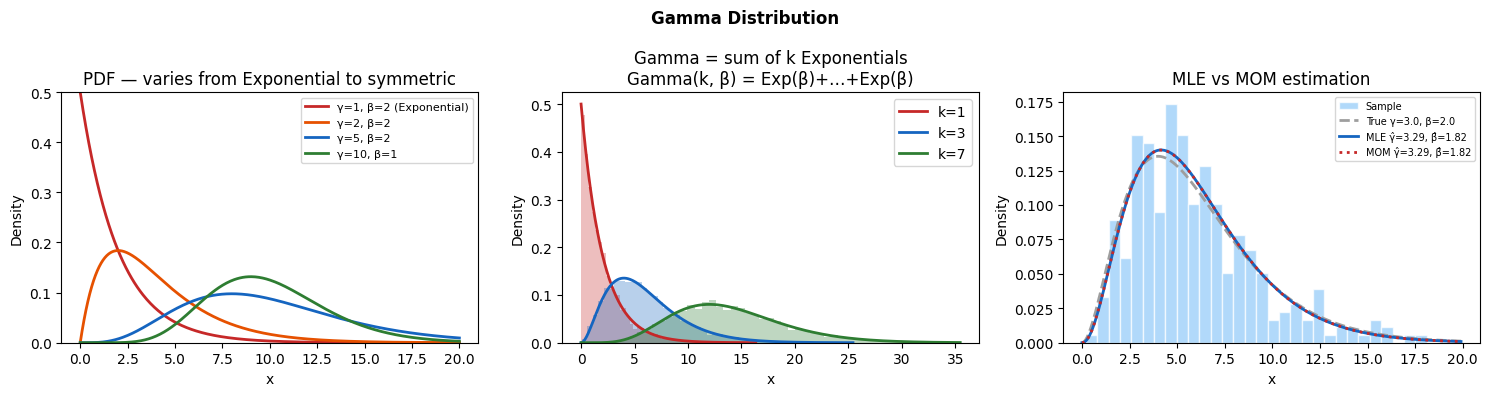

In [2]:
x = np.linspace(0.001, 20, 400)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Gamma Distribution', fontsize=12, fontweight='bold')

# PDF — scipy: a=shape(γ), scale=β
for gamma, beta, color, label in [(1,   2, '#C62828', 'γ=1, β=2 (Exponential)'),
                                    (2,   2, '#E65100', 'γ=2, β=2'),
                                    (5,   2, '#1565C0', 'γ=5, β=2'),
                                    (10,  1, '#2E7D32', 'γ=10, β=1')]:
    axes[0].plot(x, stats.gamma(a=gamma, scale=beta).pdf(x), color=color, linewidth=2, label=label)
axes[0].set_title('PDF — varies from Exponential to symmetric')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].set_ylim(0, 0.5)
axes[0].legend(fontsize=8)

# Relationship: Gamma(k, β) = sum of k Exponential(β)
np.random.seed(42)
beta_val = 2.0
n_sim = 5000
for k, color, label in [(1, '#C62828', 'k=1'), (3, '#1565C0', 'k=3'), (7, '#2E7D32', 'k=7')]:
    # Sum of k Exponentials
    summed = np.sum(stats.expon(scale=beta_val).rvs((n_sim, k)), axis=1)
    x_range = np.linspace(0, summed.max(), 300)
    axes[1].hist(summed, bins=50, density=True, alpha=0.3, color=color)
    axes[1].plot(x_range, stats.gamma(a=k, scale=beta_val).pdf(x_range), color=color, linewidth=2, label=label)
axes[1].set_title('Gamma = sum of k Exponentials\nGamma(k, β) = Exp(β)+…+Exp(β)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('Density')
axes[1].legend()

# MOM and MLE fit
true_gamma, true_beta = 3.0, 2.0
data = stats.gamma(a=true_gamma, scale=true_beta).rvs(300, random_state=42)

# MOM
xbar, s2 = data.mean(), data.var()
beta_mom = s2 / xbar
gamma_mom = xbar / beta_mom

# MLE
gamma_mle, loc_mle, beta_mle = stats.gamma.fit(data, floc=0)

x_plot = np.linspace(0, data.max()*1.1, 300)
axes[2].hist(data, bins=30, density=True, color='#90CAF9', edgecolor='white', alpha=0.7, label='Sample')
axes[2].plot(x_plot, stats.gamma(a=true_gamma, scale=true_beta).pdf(x_plot),
             color='#9E9E9E', linewidth=2, linestyle='--', label=f'True γ={true_gamma}, β={true_beta}')
axes[2].plot(x_plot, stats.gamma(a=gamma_mle, scale=beta_mle).pdf(x_plot),
             color='#1565C0', linewidth=2, label=f'MLE γ̂={gamma_mle:.2f}, β̂={beta_mle:.2f}')
axes[2].plot(x_plot, stats.gamma(a=gamma_mom, scale=beta_mom).pdf(x_plot),
             color='#C62828', linewidth=2, linestyle=':', label=f'MOM γ̂={gamma_mom:.2f}, β̂={beta_mom:.2f}')
axes[2].set_title('MLE vs MOM estimation')
axes[2].set_xlabel('x'); axes[2].set_ylabel('Density')
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()

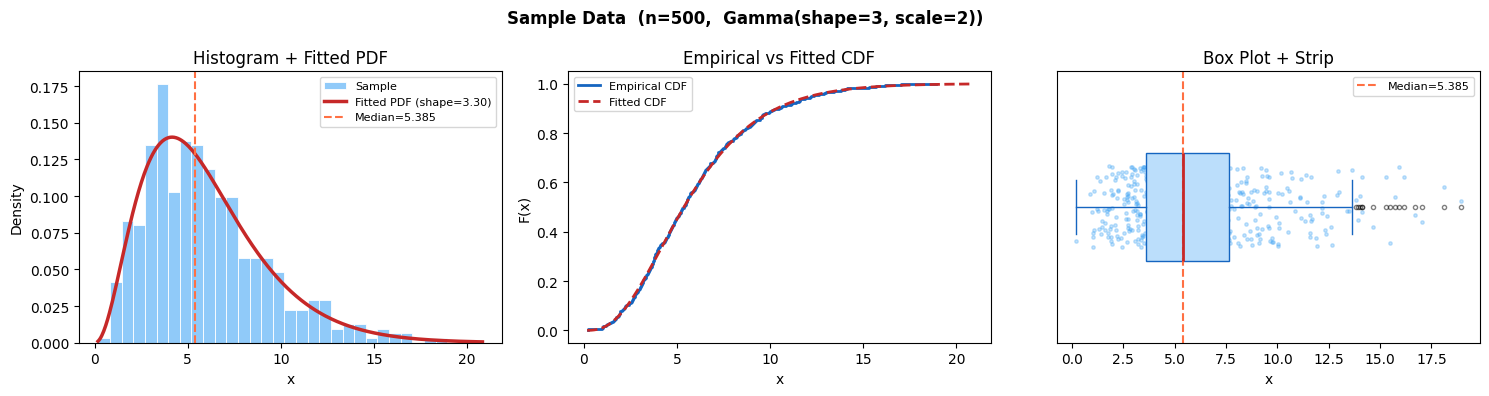

n=500  mean=5.9704  median=5.3848  std=3.2810  skew=1.0094  kurtosis=1.0164


In [3]:
# Sample data plots — Gamma(shape=3, scale=2)
np.random.seed(42)
sample_d = stats.gamma.rvs(a=3, scale=2, size=500)
a_hat, loc_hat, scale_hat = stats.gamma.fit(sample_d, floc=0)
x_fit = np.linspace(sample_d.min() * 0.9, sample_d.max() * 1.1, 400)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Sample Data  (n=500,  Gamma(shape=3, scale=2))', fontsize=12, fontweight='bold')

# Histogram + fitted PDF
axes[0].hist(sample_d, bins=30, density=True,
             color='#90CAF9', edgecolor='white', linewidth=0.6, label='Sample')
axes[0].plot(x_fit, stats.gamma(a_hat, loc_hat, scale_hat).pdf(x_fit),
             color='#C62828', linewidth=2.5, label=f'Fitted PDF (shape={a_hat:.2f})')
axes[0].axvline(np.median(sample_d), color='#FF7043', linewidth=1.5, linestyle='--',
                label=f'Median={np.median(sample_d):.3f}')
axes[0].set_title('Histogram + Fitted PDF')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# Empirical vs fitted CDF
sorted_s = np.sort(sample_d)
ecdf = np.arange(1, len(sorted_s) + 1) / len(sorted_s)
axes[1].step(sorted_s, ecdf, color='#1565C0', linewidth=2, label='Empirical CDF')
axes[1].plot(x_fit, stats.gamma(a_hat, loc_hat, scale_hat).cdf(x_fit),
             color='#C62828', linewidth=2, linestyle='--', label='Fitted CDF')
axes[1].set_title('Empirical vs Fitted CDF')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)')
axes[1].legend(fontsize=8)

# Box plot + strip
axes[2].boxplot(sample_d, vert=False, patch_artist=True, widths=0.4,
                boxprops=dict(facecolor='#BBDEFB', color='#1565C0'),
                medianprops=dict(color='#C62828', linewidth=2),
                whiskerprops=dict(color='#1565C0'),
                capprops=dict(color='#1565C0'),
                flierprops=dict(marker='o', color='#FF7043', markersize=3, alpha=0.5))
axes[2].scatter(sample_d, np.random.uniform(0.85, 1.15, len(sample_d)),
                color='#42A5F5', s=6, alpha=0.3)
axes[2].axvline(np.median(sample_d), color='#FF7043', linewidth=1.5, linestyle='--',
                label=f'Median={np.median(sample_d):.3f}')
axes[2].set_title('Box Plot + Strip')
axes[2].set_xlabel('x'); axes[2].set_yticks([])
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()
print(f"n={len(sample_d)}  mean={sample_d.mean():.4f}  median={np.median(sample_d):.4f}  std={sample_d.std(ddof=1):.4f}  skew={stats.skew(sample_d):.4f}  kurtosis={stats.kurtosis(sample_d):.4f}")


## Key Takeaways

| | |
|---|---|
| **Special cases** | $\gamma=1 \to \text{Exponential}$; $\gamma=\nu/2, \beta=2 \to \chi^2(\nu)$ |
| **Additive** | Sum of $k$ independent $\text{Gamma}(\gamma,\beta) \sim \text{Gamma}(k\gamma,\beta)$ |
| **Sum of Exponentials** | $k$ independent $\text{Exp}(\beta)$ variables sum to $\text{Gamma}(k, \beta)$ |
| **Skewness** | $2/\sqrt{\gamma}$ — decreases as $\gamma$ increases; approaches Normal at large $\gamma$ |
| **MOM** | $\hat{\gamma} = \bar{x}^2/s^2$, $\hat{\beta} = s^2/\bar{x}$ — simple closed form |
| **Use cases** | Waiting time for $k$ events, rainfall totals, insurance claim sizes, Bayesian conjugate prior for Poisson rate |
